<center><h1>Lanka_VenkataSriSaiPavani_HW3</h1></center>
<br>
<br>

Name: Venkata Sri Sai Pavani Lanka
<br>
Github Username: lanka1908
<br>
USC ID: 4885549248

## 1. Time Series Classification Part 1: Feature Creation/Extraction

### (a) Download Data

Package imports

In [6]:
import pandas as pd
import os
import csv
import numpy as np
from scipy.stats import bootstrap

Get the AReM Data Set

In [8]:
data_dir = '../data/AReM/'

Found that there were some trailing comas and spaces in line 485 of dataset9.csv & dataset14.csv of cycling folder so removed them and changed the format of dataset4.csv of bending2 using excel by adding the delimiter space.

### (b) Test and Train Data

In [11]:
# Chatgpt reference

folders = {
    'bending1': os.path.join(data_dir, 'bending1'),
    'bending2': os.path.join(data_dir, 'bending2'),
    'cycling': os.path.join(data_dir, 'cycling'),
    'lying': os.path.join(data_dir, 'lying'),
    'sitting': os.path.join(data_dir, 'sitting'),
    'standing': os.path.join(data_dir, 'standing'),
    'walking': os.path.join(data_dir, 'walking'),
}  

training_set = []
test_set = []

def add_files_to_training(folder, exclude_files):
    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)
        if os.path.isfile(file_path) and file_name not in exclude_files:
            training_set.append(file_path)

for folder_name in ['bending1', 'bending2']:
    for file_name in ['dataset1.csv', 'dataset2.csv']:
        test_set.append(os.path.join(folders[folder_name], file_name))

for folder_name in ['cycling', 'lying', 'sitting', 'standing', 'walking']:
    for file_name in ['dataset1.csv', 'dataset2.csv', 'dataset3.csv']:
        test_set.append(os.path.join(folders[folder_name], file_name))

for folder_name in ['bending1', 'bending2']:
    add_files_to_training(folders[folder_name], ['dataset1.csv', 'dataset2.csv'])

for folder_name in ['cycling', 'lying', 'sitting', 'standing', 'walking']:
    add_files_to_training(folders[folder_name], ['dataset1.csv', 'dataset2.csv', 'dataset3.csv'])

print("\nTraining Set:")
for file in training_set:
    print(file)

print("\nTest Set:")
for file in test_set:
    print(file)

print(f"\nNumber of files in the Training Set: {len(training_set)}")
print(f"\nNumber of files in the Test Set: {len(test_set)}")


Training Set:
../data/AReM/bending1\dataset3.csv
../data/AReM/bending1\dataset4.csv
../data/AReM/bending1\dataset5.csv
../data/AReM/bending1\dataset6.csv
../data/AReM/bending1\dataset7.csv
../data/AReM/bending2\dataset3.csv
../data/AReM/bending2\dataset4.csv
../data/AReM/bending2\dataset5.csv
../data/AReM/bending2\dataset6.csv
../data/AReM/cycling\dataset10.csv
../data/AReM/cycling\dataset11.csv
../data/AReM/cycling\dataset12.csv
../data/AReM/cycling\dataset13.csv
../data/AReM/cycling\dataset14.csv
../data/AReM/cycling\dataset15.csv
../data/AReM/cycling\dataset4.csv
../data/AReM/cycling\dataset5.csv
../data/AReM/cycling\dataset6.csv
../data/AReM/cycling\dataset7.csv
../data/AReM/cycling\dataset8.csv
../data/AReM/cycling\dataset9.csv
../data/AReM/lying\dataset10.csv
../data/AReM/lying\dataset11.csv
../data/AReM/lying\dataset12.csv
../data/AReM/lying\dataset13.csv
../data/AReM/lying\dataset14.csv
../data/AReM/lying\dataset15.csv
../data/AReM/lying\dataset4.csv
../data/AReM/lying\dataset

### (c) Feature Extraction

#### i. Research

According to my research, these are some of the time domain features that we can use for time series classification:

minimum

maximum

mean

median

range

root mean square

standard deviation

first quartile

third quartile

skewness

kurtosis

#### ii. Extraction

In [16]:
#Chatgpt Reference

instances = []

def extract_features(file_path):
    try:
        df = pd.read_csv(file_path, skiprows=4, on_bad_lines='skip', delimiter=',')
        
        print(f"Columns in {file_path}: {df.columns.tolist()}")
        
        features = {}

        naming_scheme = {
            'avg_rss12': [1, 'avg'],
            'var_rss12': [2, 'var'],
            'avg_rss13': [3, 'avg'],
            'var_rss13': [4, 'var'],
            'avg_rss23': [5, 'avg'],
            'var_rss23': [6, 'var']
        }
        
        # Took this part of the code from chatgpt.. mentioned the prompt in refrences
        
        for col, (index, var_type) in naming_scheme.items():
            if col in df.columns: 
                features[f'min{index}'] = df[col].min()
                features[f'max{index}'] = df[col].max()
                features[f'mean{index}'] = df[col].mean()
                features[f'median{index}'] = df[col].median()
                features[f'std{index}'] = df[col].std()
                features[f'1st_quart{index}'] = df[col].quantile(0.25)
                features[f'3rd_quart{index}'] = df[col].quantile(0.75)
            else:
                print(f"Column {col} not found in {file_path}.")

        return features

    except pd.errors.ParserError as e:
        print(f"Error parsing {file_path}: {e}")
        return None 

# Took reference for this part of the code from chatgpt.. mentioned the prompt in refrences
for activity in os.listdir(data_dir):
    activity_path = os.path.join(data_dir, activity)
    if os.path.isdir(activity_path):
        for file in os.listdir(activity_path):
            if file.endswith('.csv'):
                file_path = os.path.join(activity_path, file)
                instance_features = extract_features(file_path)
                if instance_features: 
                    instances.append(instance_features)

features_df = pd.DataFrame(instances)
features_df.insert(0, 'Instance', range(1, len(features_df) + 1))

output_path = '../data/AReM/features_dataset.csv' 
features_df.to_csv(output_path, index=False)

print("Feature extraction complete. The new dataset has been saved.")

Columns in ../data/AReM/bending1\dataset1.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
Columns in ../data/AReM/bending1\dataset2.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
Columns in ../data/AReM/bending1\dataset3.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
Columns in ../data/AReM/bending1\dataset4.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
Columns in ../data/AReM/bending1\dataset5.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
Columns in ../data/AReM/bending1\dataset6.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
Columns in ../data/AReM/bending1\dataset7.csv: ['# Columns: time', 'avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23'

#### iii. Standard Deviation

In [18]:
#Google Search reference

features_df = pd.read_csv('../data/AReM/features_dataset.csv')
std_deviations = features_df.std()

confidence_intervals = {}

for feature in std_deviations.index:
    data = features_df[feature].values
    result = bootstrap((data,), np.std, confidence_level = 0.90, n_resamples=1000, method='basic')
    confidence_intervals[feature] = result.confidence_interval

print("Standard Deviations and 90% Bootstrap Confidence Intervals:")
for feature, std in std_deviations.items():
    ci = confidence_intervals[feature]
    print(f"{feature}: Standard Deviation = {std:.4f}, 90% Confidence Interval = ({ci.low:.4f}, {ci.high:.4f})")

Standard Deviations and 90% Bootstrap Confidence Intervals:
Instance: Standard Deviation = 25.5473, 90% Confidence Interval = (23.5963, 27.5923)
min1: Standard Deviation = 9.5700, 90% Confidence Interval = (8.3291, 10.8290)
max1: Standard Deviation = 4.3944, 90% Confidence Interval = (3.4651, 5.4527)
mean1: Standard Deviation = 5.3357, 90% Confidence Interval = (4.7288, 5.9185)
median1: Standard Deviation = 5.4401, 90% Confidence Interval = (4.8496, 6.0786)
std1: Standard Deviation = 1.7722, 90% Confidence Interval = (1.5813, 1.9591)
1st_quart1: Standard Deviation = 6.1536, 90% Confidence Interval = (5.6373, 6.7034)
3rd_quart1: Standard Deviation = 5.1389, 90% Confidence Interval = (4.4348, 5.8727)
min2: Standard Deviation = 0.0000, 90% Confidence Interval = (0.0000, 0.0000)
max2: Standard Deviation = 5.0627, 90% Confidence Interval = (4.6675, 5.4733)
mean2: Standard Deviation = 1.5742, 90% Confidence Interval = (1.4333, 1.7389)
median2: Standard Deviation = 1.4122, 90% Confidence Inte

#### iv. Select Features

The three most important time-domain features are:

Mean: The mean gives us a central measure of the data, that helps us in estimating the typical value over an observed period.

Maximum: The maximum value gives us the extreme level of an activity, which can be beneficial for situations when extreme values indicate significant changes or behaviors.

Standard deviation: It measures the variation around the mean, indicating deviation of the values from the mean, so considering this would be important, as it can tell about if the variablility in the data is manageable or not.

## 2. ISLR 3.7.4

### (a) Linear Train

Since the true relationship is linear in this case, even though the training RSS will be small for Linear Regression, however, the training data will fit better to the cubic regression as it is more flexible and hence provide smaller RSS.

### (b) Linear Test

For Test RSS, Linear Regression model will have a lower RSS compared to the one fitted with cubic regression as it reduces the unnecessary complexity that the cubic model can incur and there's a chance that the cubic model may also capture noise that may lead to higher RSS.

### (c) Not Linear Train

If the relationship is not linear and also unknown, the training RSS for linear model might be higher than the cubic model, as it won't be able to capture the underlying patterns.

### (d) Not Linear Testing

The test RSS for the cubic model would be lower compared to the linear regression model as it will not be able to capture the true non linear patterns in the data in the linear model.

## 3. ISLR 3.7.3 - Extra Practice 

## 3. ISLR 3.7.5 - Extra Practice 

# Citations & References

1.(b) Chatgpt Reference:
prompt: if i have to choose files from 2 different folders, as my training set how do i do that in python? they are not random files, i have to choose specific files

chatgpt response:
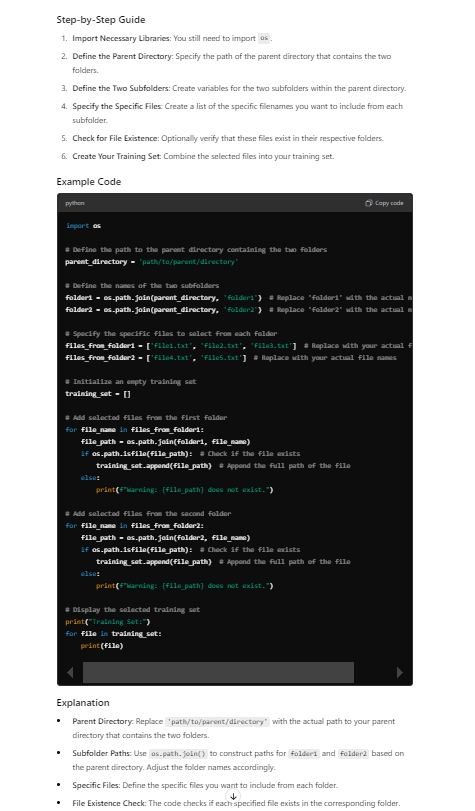

prompt: 
okay and if after adding the specified files to the training set, i want to make a test set as well that has all the remaining files from both of these folders.

chatgpt response:
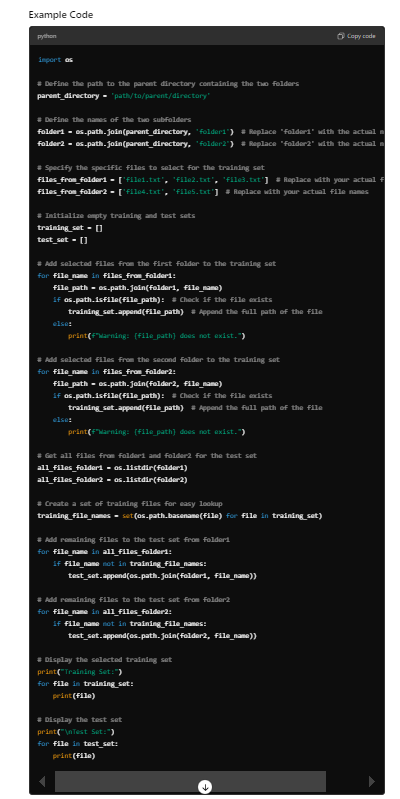

1.(c).(i) Google search:
Searched for:
what types of time-domain features are usually used in time series classification?
Top search result:
Classification of time series usually needs extracting features from them. So, extract the time-domain features such as minimum, maximum, mean, median, standard deviation, first quartile, and third quartile for all the 6 time series in each instance.
https://stats.stackexchange.com/questions/50807/features-for-time-series-classification
https://medium.com/@dreamferus/time-series-feature-extraction-using-pandas-44af6fb5fce9
https://medium.datadriveninvestor.com/time-series-classification-using-feature-extraction-16209570a22e

1.(c).(ii) Chatgpt Reference:
prompt: how can i Extract the time-domain features minimum, maximum, mean, median, standard deviation, first quartile, and third quartile for all of the time series in each instance, which is each csv file that is stored in a parent directory?

chatgpt response:
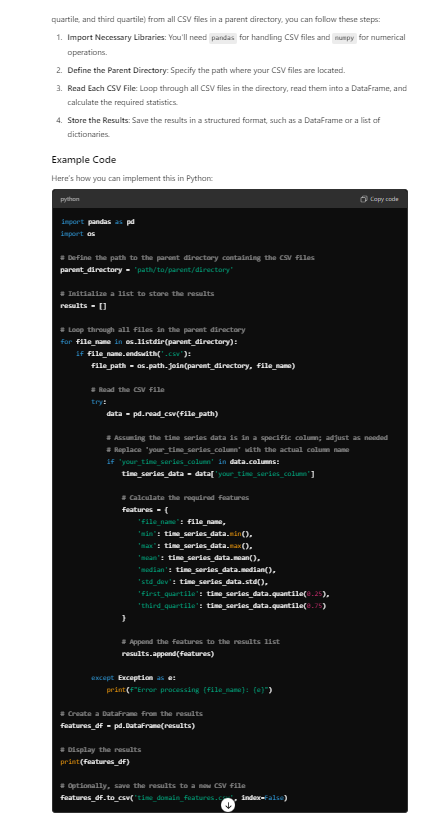

1.c.(iii) Google Search:
Searched for: 
bootstrapped confidence intervals python
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html
https://towardsdatascience.com/calculating-confidence-interval-with-bootstrapping-872c657c058d

1.c.(iv) Chatgpt Reference:
prompt: How do I determine the most important time domain features for a time series classification?

Response: Determining the most important features in a dataset, particularly for time-series classification, involves a combination of statistical analysis, domain knowledge, and practical experimentation. Here are some methods to help you select the most important time-domain features:

1. Statistical Analysis
Correlation Analysis: Check how strongly each feature correlates with the target variable. Features that have a higher correlation (either positive or negative) with the target may be more important.
You can use Pearson's correlation coefficient for continuous features.
Variance Analysis: Features with higher variance might be more informative. If a feature has little variation, it may not contribute much to distinguishing between classes.
2. Feature Importance from Models
Tree-based Models: Use models like Random Forests or Gradient Boosting Machines (GBM) that provide feature importance scores. After training the model, you can inspect which features have the most impact on predictions.
Recursive Feature Elimination (RFE): This method uses a model to evaluate feature importance iteratively and removes the least important features until you reach a desired number.
3. Domain Knowledge
Leverage your understanding of the problem domain. Some features may have a theoretical basis for being important based on what they represent.
Consider which features are known to be critical in similar studies or applications. For instance, if you’re dealing with physical signals, features like minimum, maximum, and mean are often crucial.
4. Experimentation
Cross-validation: Test different combinations of features in your classification model using cross-validation to see which combination yields the best performance.
Model Performance: Track the accuracy, precision, recall, or F1-score of your model as you include or exclude different features.
5. Feature Selection Techniques
Univariate Selection: Use statistical tests to select features that have the strongest relationship with the output variable. This can include t-tests for comparing means or ANOVA for multiple classes.
L1 Regularization: Using models like Lasso regression can help in feature selection by penalizing less important features.
Example of Selecting Features
For instance, if you are considering selecting min, mean, and max:

Min: Provides information about the lowest activity level, which might be significant in detecting certain behaviors.
Mean: Offers an average representation of the activity level, crucial for understanding overall trends.
Max: Indicates the highest activity level, which can be critical in cases where peaks matter (e.g., detecting bursts of activity).
Practical Steps
Conduct a Correlation Analysis: Use Python to compute correlations between your features and the target variable.
Use a Machine Learning Model: Train a Random Forest or similar model to get feature importances.
Combine Insights: Use domain knowledge and model insights to choose the three features that you believe will be most impactful.